In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Fetching actual generation data...")
actual_data = []
for day in range(1, 32):
    date_str = f"2024-01-{day:02d}"
    next_date = f"2024-01-{(day+1):02d}" if day < 31 else "2024-02-01"
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom={date_str}&settlementDateTo={next_date}"
    r = requests.get(url)
    data = r.json()
    wind = [d for d in data if d.get('fuelType') == 'WIND']
    actual_data.extend(wind)
    print(f"Day {day}: {len(wind)} records")

df_actual = pd.DataFrame(actual_data)
df_actual['startTime'] = pd.to_datetime(df_actual['startTime'])
print(f"\nTotal actual records: {len(df_actual)}")
df_actual.head()

Fetching actual generation data...
Day 1: 96 records
Day 2: 96 records
Day 3: 96 records
Day 4: 96 records
Day 5: 96 records
Day 6: 96 records
Day 7: 96 records
Day 8: 96 records
Day 9: 96 records
Day 10: 96 records
Day 11: 96 records
Day 12: 96 records
Day 13: 96 records
Day 14: 96 records
Day 15: 96 records
Day 16: 96 records
Day 17: 96 records
Day 18: 96 records
Day 19: 96 records
Day 20: 96 records
Day 21: 96 records
Day 22: 96 records
Day 23: 96 records
Day 24: 96 records
Day 25: 96 records
Day 26: 96 records
Day 27: 96 records
Day 28: 96 records
Day 29: 96 records
Day 30: 96 records
Day 31: 96 records

Total actual records: 2976


,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-01-03T00:00:00Z,2024-01-02 23:30:00+00:00,2024-01-02,48,WIND,10922
1,FUELHH,2024-01-02T23:30:00Z,2024-01-02 23:00:00+00:00,2024-01-02,47,WIND,10992
2,FUELHH,2024-01-02T23:00:00Z,2024-01-02 22:30:00+00:00,2024-01-02,46,WIND,11364
3,FUELHH,2024-01-02T22:30:00Z,2024-01-02 22:00:00+00:00,2024-01-02,45,WIND,11480
4,FUELHH,2024-01-02T22:00:00Z,2024-01-02 21:30:00+00:00,2024-01-02,44,WIND,11467


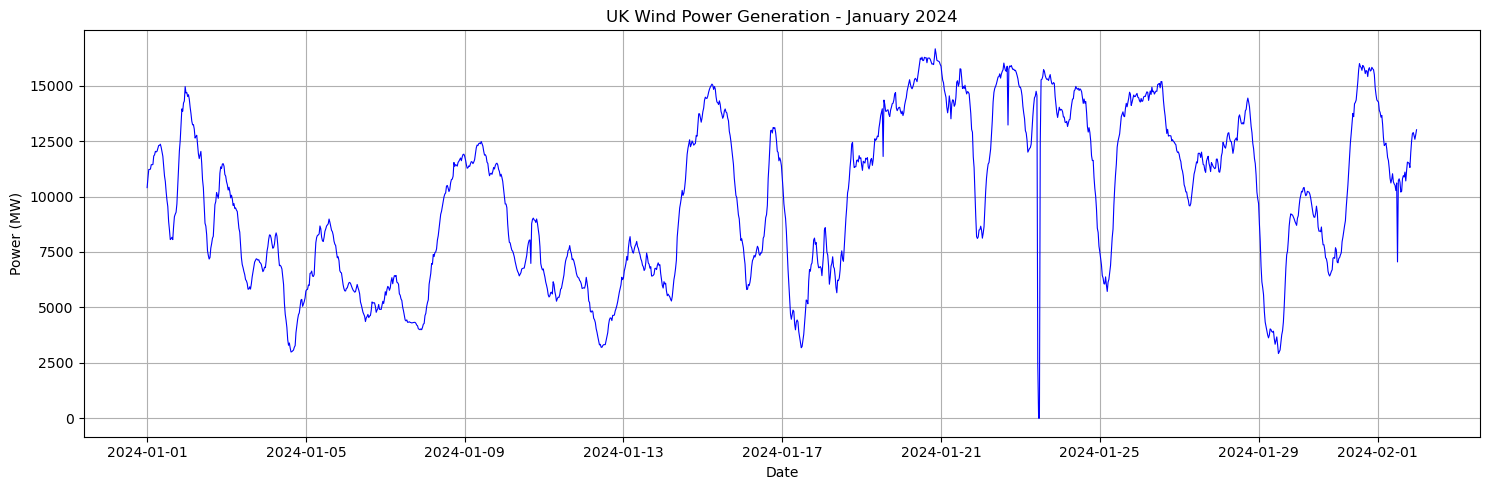

Min generation: 0 MW
Max generation: 16662 MW
Mean generation: 9857 MW
Median generation: 9946 MW


In [2]:
# Sort by time
df_actual = df_actual.sort_values('startTime').reset_index(drop=True)

# Plot actual wind generation for January 2024
plt.figure(figsize=(15, 5))
plt.plot(df_actual['startTime'], df_actual['generation'], color='blue', linewidth=0.8)
plt.title('UK Wind Power Generation - January 2024')
plt.xlabel('Date')
plt.ylabel('Power (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Min generation: {df_actual['generation'].min()} MW")
print(f"Max generation: {df_actual['generation'].max()} MW")
print(f"Mean generation: {df_actual['generation'].mean():.0f} MW")
print(f"Median generation: {df_actual['generation'].median():.0f} MW")

In [3]:
# Fetch forecast data for January 2024
print("Fetching forecast data...")
forecast_data = []

# Fetch month by month going back 35 days
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream?publishDateTimeFrom=2023-12-01T00:00:00Z&publishDateTimeTo=2024-01-31T23:59:59Z"
r = requests.get(url)
forecast_data = r.json()

df_forecast = pd.DataFrame(forecast_data)
df_forecast['startTime'] = pd.to_datetime(df_forecast['startTime'])
df_forecast['publishTime'] = pd.to_datetime(df_forecast['publishTime'])

# Filter only January 2024 target times
df_forecast = df_forecast[df_forecast['startTime'].dt.month == 1]
df_forecast = df_forecast[df_forecast['startTime'].dt.year == 2024]

# Calculate forecast horizon in hours
df_forecast['horizon_hours'] = (df_forecast['startTime'] - df_forecast['publishTime']).dt.total_seconds() / 3600

# Filter 0-48 hours horizon
df_forecast = df_forecast[(df_forecast['horizon_hours'] >= 0) & (df_forecast['horizon_hours'] <= 48)]

print(f"Total forecast records: {len(df_forecast)}")
df_forecast.head()

Fetching forecast data...
Total forecast records: 9582


,dataset,publishTime,startTime,generation,horizon_hours
2,WINDFOR,2024-01-31 22:30:00+00:00,2024-01-31 23:00:00+00:00,16909,0.5
49,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 21:00:00+00:00,17912,2.5
50,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 22:00:00+00:00,17670,3.5
51,WINDFOR,2024-01-31 18:30:00+00:00,2024-01-31 23:00:00+00:00,17275,4.5
98,WINDFOR,2024-01-31 15:30:00+00:00,2024-01-31 21:00:00+00:00,17887,5.5


In [4]:
# Match actuals with forecasts and calculate errors
# For each target time, find the latest forecast with horizon >= 4 hours

df_actual_sorted = df_actual.sort_values('startTime').reset_index(drop=True)

# Floor actual startTime to nearest hour for matching
df_actual_sorted['hourKey'] = df_actual_sorted['startTime'].dt.floor('h')

# For each horizon bucket, find best forecast
results = []

for _, actual_row in df_actual_sorted.iterrows():
    target = actual_row['startTime']
    actual_gen = actual_row['generation']
    
    # Get all forecasts for this target time
    forecasts_for_target = df_forecast[df_forecast['startTime'].dt.floor('h') == target.floor('h')]
    
    if len(forecasts_for_target) == 0:
        continue
    
    for _, fc_row in forecasts_for_target.iterrows():
        results.append({
            'startTime': target,
            'actual': actual_gen,
            'forecast': fc_row['generation'],
            'horizon_hours': fc_row['horizon_hours'],
            'publishTime': fc_row['publishTime']
        })

df_errors = pd.DataFrame(results)
df_errors['error'] = df_errors['forecast'] - df_errors['actual']
df_errors['abs_error'] = df_errors['error'].abs()

print(f"Total matched records: {len(df_errors)}")
print(f"\nOverall Error Stats:")
print(f"Mean Error (Bias): {df_errors['error'].mean():.0f} MW")
print(f"Mean Absolute Error: {df_errors['abs_error'].mean():.0f} MW")
print(f"Median Absolute Error: {df_errors['abs_error'].median():.0f} MW")
print(f"P99 Absolute Error: {df_errors['abs_error'].quantile(0.99):.0f} MW")

Total matched records: 37710

Overall Error Stats:
Mean Error (Bias): 1359 MW
Mean Absolute Error: 2085 MW
Median Absolute Error: 1788 MW
P99 Absolute Error: 7373 MW


C:\Users\HP\AppData\Local\Temp\ipykernel_8240\3755387758.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  horizon_stats = df_errors.groupby('horizon_bucket')['abs_error'].agg(['mean', 'median']).reset_index()


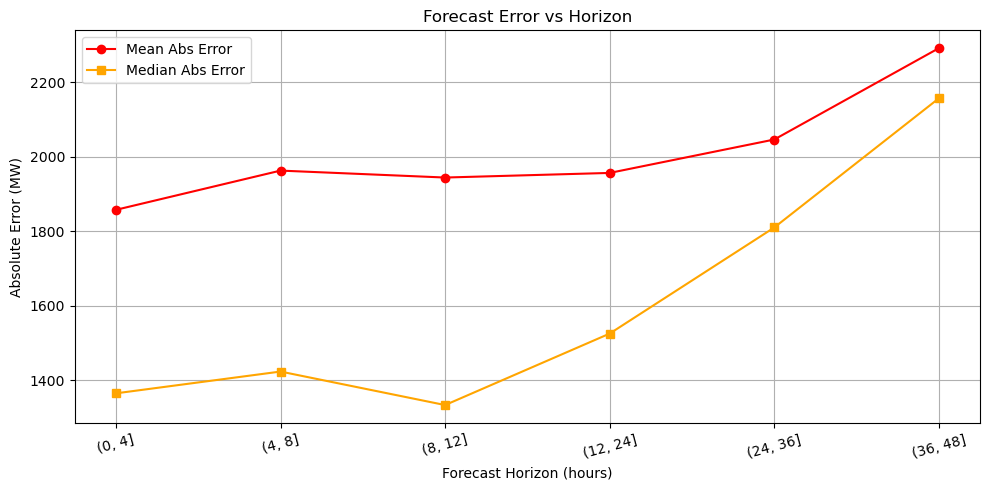

  horizon_bucket         mean  median
0         (0, 4]  1857.445355  1364.5
1         (4, 8]  1962.842963  1423.0
2        (8, 12]  1944.205010  1333.0
3       (12, 24]  1956.585632  1525.0
4       (24, 36]  2046.332309  1810.0
5       (36, 48]  2291.718292  2157.0


In [5]:
# Error variation by forecast horizon
horizon_bins = [0, 4, 8, 12, 24, 36, 48]
df_errors['horizon_bucket'] = pd.cut(df_errors['horizon_hours'], bins=horizon_bins)

horizon_stats = df_errors.groupby('horizon_bucket')['abs_error'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(range(len(horizon_stats)), horizon_stats['mean'], marker='o', label='Mean Abs Error', color='red')
plt.plot(range(len(horizon_stats)), horizon_stats['median'], marker='s', label='Median Abs Error', color='orange')
plt.xticks(range(len(horizon_stats)), [str(b) for b in horizon_stats['horizon_bucket']], rotation=15)
plt.title('Forecast Error vs Horizon')
plt.xlabel('Forecast Horizon (hours)')
plt.ylabel('Absolute Error (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(horizon_stats)

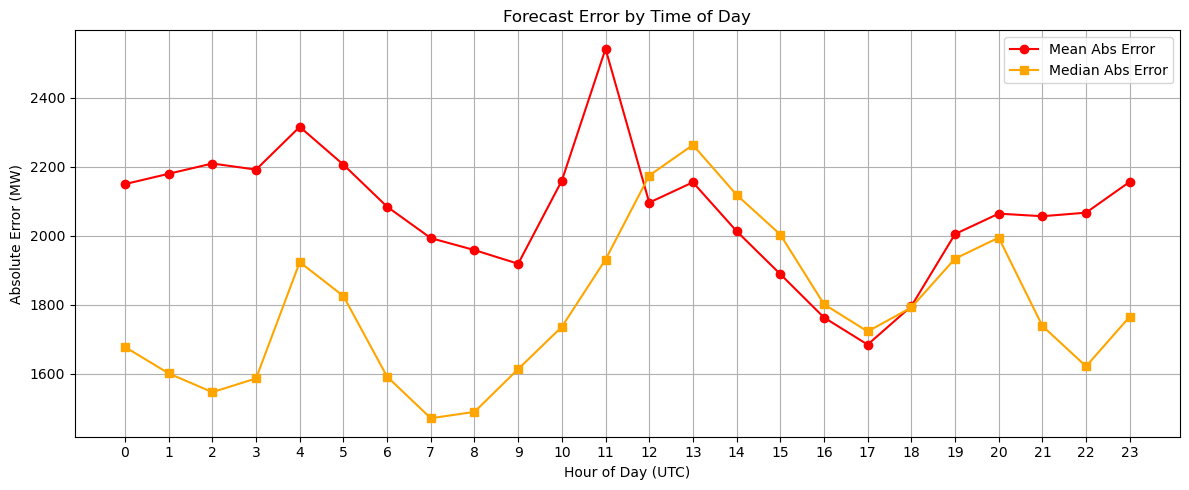


--- Reliable Wind Power Analysis ---
Total actual records: 2976
P10 generation (reliable floor): 5086 MW
P20 generation: 6248 MW
P25 generation: 6732 MW
Percentage of time generation > 5000 MW: 90.5%
Percentage of time generation > 3000 MW: 99.7%


In [6]:
# Error at different times of day
df_errors['hour'] = df_errors['startTime'].dt.hour

hour_stats = df_errors.groupby('hour')['abs_error'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hour_stats['hour'], hour_stats['mean'], marker='o', label='Mean Abs Error', color='red')
plt.plot(hour_stats['hour'], hour_stats['median'], marker='s', label='Median Abs Error', color='orange')
plt.title('Forecast Error by Time of Day')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Absolute Error (MW)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Reliable wind power recommendation
print("\n--- Reliable Wind Power Analysis ---")
print(f"Total actual records: {len(df_actual)}")
print(f"P10 generation (reliable floor): {df_actual['generation'].quantile(0.10):.0f} MW")
print(f"P20 generation: {df_actual['generation'].quantile(0.20):.0f} MW")
print(f"P25 generation: {df_actual['generation'].quantile(0.25):.0f} MW")
print(f"Percentage of time generation > 5000 MW: {(df_actual['generation'] > 5000).mean()*100:.1f}%")
print(f"Percentage of time generation > 3000 MW: {(df_actual['generation'] > 3000).mean()*100:.1f}%")

In [7]:
# Final recommendation
print("=" * 60)
print("RELIABLE WIND POWER RECOMMENDATION")
print("=" * 60)
print("""
Based on January 2024 UK wind generation data:

KEY FINDINGS:
- Mean generation: 9,857 MW
- Median generation: 9,946 MW  
- P10 (reliable floor): 5,086 MW
- Wind exceeded 5,000 MW 90.5% of the time
- Wind exceeded 3,000 MW 99.7% of the time

RECOMMENDATION:
We recommend 5,000 MW as the reliable wind power 
baseline that can be counted on to meet electricity demand.

REASONING:
- 90.5% availability means only 1 in 10 half-hour periods
  fall below this level in January 2024
- This is a conservative but realistic estimate
- Grid operators should plan backup capacity for the 
  remaining 9.5% of time when wind drops below 5,000 MW
- For critical demand periods, 3,000 MW is extremely 
  reliable at 99.7% availability

FORECAST ERROR SUMMARY:
- Mean Absolute Error: 2,085 MW
- Error grows with horizon: 1,857 MW (0-4h) to 2,291 MW (36-48h)
- Forecasts have a positive bias of 1,359 MW (over-forecasting)
""")

RELIABLE WIND POWER RECOMMENDATION

Based on January 2024 UK wind generation data:

KEY FINDINGS:
- Mean generation: 9,857 MW
- Median generation: 9,946 MW  
- P10 (reliable floor): 5,086 MW
- Wind exceeded 5,000 MW 90.5% of the time
- Wind exceeded 3,000 MW 99.7% of the time

RECOMMENDATION:
We recommend 5,000 MW as the reliable wind power 
baseline that can be counted on to meet electricity demand.

REASONING:
- 90.5% availability means only 1 in 10 half-hour periods
  fall below this level in January 2024
- This is a conservative but realistic estimate
- Grid operators should plan backup capacity for the 
  remaining 9.5% of time when wind drops below 5,000 MW
- For critical demand periods, 3,000 MW is extremely 
  reliable at 99.7% availability

FORECAST ERROR SUMMARY:
- Mean Absolute Error: 2,085 MW
- Error grows with horizon: 1,857 MW (0-4h) to 2,291 MW (36-48h)
- Forecasts have a positive bias of 1,359 MW (over-forecasting)

